# 산점도 찍는 함수

정제된 csv파일을 통해 산점도를 찍음.

In [79]:
import pandas as pd # 데이터 처리 라이브러리

# 데이터프레임 전처리 함수
def clean_and_prepare_dataframe(df):
    df['total'] = True  # 모든 행에 대해 'total' 열을 True로 설정하여 전체 분석에 사용할 수 있도록 함

    # -----------------------------
    # 1. 열 이름(column name) 앞뒤 공백 제거
    # -----------------------------
    df.columns = df.columns.str.strip()
    print("열 이름 앞뒤 공백 제거 완료. \n현재 열 이름:", df.columns.tolist())

    # -----------------------------
    # 2. category 열 내용 앞뒤 공백 제거
    # -----------------------------
    if "category" in df.columns:
        df["category"] = df["category"].astype(str).str.strip()
        print("category 열 내용 앞뒤 공백 제거 완료. 현재 category 값:", df["category"].unique())

    else:
        #document 파일 읽기, 'docu_었_결합_등급', 'docu_었_결합_성향' 컬럼만 추출하여 df와 병합
        DOCU_CSV = r"..\csv\original_csv\세종문어_document_정보_ver.1.2.csv"
        df_docu = pd.read_csv(DOCU_CSV, low_memory=False)
        df_docu = df_docu[['docu_id', 'category', 'docu_었_결합_등급', 'docu_었_결합_성향']]
        df = df.merge(df_docu, on='docu_id', how='left')


        
    # category 열을 기반으로 문서범주 열 생성
    if "문서범주" not in df.columns:
        df['문서범주'] = df['category'].map({
            '보도해설':'신문', 
            '사설': '신문', 
            '칼럼': '신문', 
            '인문사회': '인문자연', 
            '체험기술': '체험', 
            '허구일반': '허구', 
            '자연': '인문자연', 
            '총류': '인문자연', 
            '허구아동': '허구'
        })
        print("문서범주 열 생성 완료. 현재 문서범주 값:", df["문서범주"].unique())
    else:
        df.loc[df["문서범주"] == "책", "문서범주"] = "인문자연"

    return df


In [46]:

# --------------------------------------------------
# 1. CSV 파일 불러오기
# --------------------------------------------------
df = pd.read_csv(r"..\csv\결과값\tense\TRI_A_by_docu_id_2026-05-23_18-30.csv") #3연쇄 분석용 CSV 파일 경로
df_2 = pd.read_csv(r"..\csv\결과값\tense\RUNS_A_by_docu_id_2026-05-24_10-06.csv") #2연쇄 분석용 CSV 파일 경로

df = clean_and_prepare_dataframe(df)
df_2 = clean_and_prepare_dataframe(df_2)

열 이름 앞뒤 공백 제거 완료. 
현재 열 이름: ['docu_id', 'n_T', 'n_F', 'n_sentences', 'P_T', 'P_F', 'TT', 'TF', 'FT', 'FF', 'n_pairs', 'P_T_given_T_pair', 'P_F_given_T_pair', 'P_T_given_F_pair', 'P_F_given_F_pair', 'TTT', 'TTF', 'TFT', 'TFF', 'FTT', 'FTF', 'FFT', 'FFF', 'n_trigrams', 'P_T_given_TT', 'P_F_given_TT', 'P_T_given_TF', 'P_F_given_TF', 'P_T_given_FT', 'P_F_given_FT', 'P_T_given_FF', 'P_F_given_FF', 'E_TTT_markov', 'E_TTF_markov', 'E_TFT_markov', 'E_TFF_markov', 'E_FTT_markov', 'E_FTF_markov', 'E_FFT_markov', 'E_FFF_markov', 'Obs_TTT_rate', 'E_TTT_markov_rate', 'TTT_markov_delta', 'TTT_markov_ratio', 'Obs_TTF_rate', 'E_TTF_markov_rate', 'TTF_markov_delta', 'TTF_markov_ratio', 'Obs_TFT_rate', 'E_TFT_markov_rate', 'TFT_markov_delta', 'TFT_markov_ratio', 'Obs_TFF_rate', 'E_TFF_markov_rate', 'TFF_markov_delta', 'TFF_markov_ratio', 'Obs_FTT_rate', 'E_FTT_markov_rate', 'FTT_markov_delta', 'FTT_markov_ratio', 'Obs_FTF_rate', 'E_FTF_markov_rate', 'FTF_markov_delta', 'FTF_markov_ratio', 'Obs_FFT_rate'

In [94]:
import matplotlib.pyplot as plt # 시각화 라이브러리
import matplotlib.font_manager as fm # 폰트 관련 모듈
import platform # 운영체제 정보 가져오기 위한 모듈
import numpy as np # 수치 계산 라이브러리
# --------------------------------------------------
# 1. 기본 설정 및 준비 함수
# --------------------------------------------------

# 1.1. 운영체제별 한글 폰트 설정 함수: Windows는 Malgun Gothic, macOS는 AppleGothic, Linux/Colab은 NanumGothic으로 설정. 마이너스 기호 깨짐 방지 설정도 포함.
def set_korean_font(): 
    """
    운영체제별 matplotlib 한글 폰트 설정
    """

    system_name = platform.system()

    if system_name == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"

    elif system_name == "Darwin":  # macOS
        plt.rcParams["font.family"] = "AppleGothic"

    else:  # Linux / Colab
        plt.rcParams["font.family"] = "NanumGothic"

    # 마이너스 기호 깨짐 방지
    plt.rcParams["axes.unicode_minus"] = False

# 1.2. 숫자 컬럼을 안전하게 변환하는 함수: 쉼표 제거, % 처리, 변환 불가능한 값은 NaN으로 처리
def clean_numeric(series, percent_to_ratio=False):
    """
    문자열 숫자를 float로 변환

    Examples
    --------
    "12.3%" -> 0.123
    "1,234" -> 1234

    Parameters
    ----------
    percent_to_ratio : bool
        True이면 %를 100으로 나눔
    """

    s = (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    has_percent = s.str.contains("%", regex=False)
    s = s.str.replace("%", "", regex=False)

    numeric = pd.to_numeric(s, errors="coerce") # 변환 불가능한 값은 NaN으로 처리

    if percent_to_ratio:
        numeric = np.where(has_percent, numeric / 100, numeric) # %가 있던 값은 100으로 나누고, 나머지는 그대로 유지
        numeric = pd.Series(numeric, index=series.index) # numpy 배열을 다시 Series로 변환하여 인덱스 유지

    return numeric

# 1.3. 전환률이 0~1 비율인지, 0~100 백분율인지 자동 판단하는 함수
def infer_probability_scale(series):
    """
    값이 0~1 비율인지, 0~100 백분율인지 자동 판단
    """
    max_val = series.dropna().max()

    if max_val <= 1:
        return "ratio"      # 0~1
    else:
        return "percent"    # 0~100

# 1.4. 산점도 그리기 위한 데이터 준비 함수: 숫자 변환, 결측치 제거, 필요한 열 선택
def prepare_xy_group_data(
    df,
    x_col,
    y_col,
    group_col=None,
    label_col=None,
    percent_to_ratio=False
):
    data = df.copy()

    data[x_col] = clean_numeric(data[x_col], percent_to_ratio=percent_to_ratio)
    data[y_col] = clean_numeric(data[y_col], percent_to_ratio=percent_to_ratio)

    use_cols = [x_col, y_col]

    if group_col is not None:
        use_cols.append(group_col)

    if label_col is not None:
        use_cols.append(label_col)

    drop_cols = [x_col, y_col]

    if group_col is not None:
        drop_cols.append(group_col)

    data = data[use_cols].dropna(subset=drop_cols)

    return data

# 1.5. 데이터 준비 후 요약 정보 출력 함수: 원본 데이터 행 수, 숫자 변환 성공한 행 수, 그래프에 사용되는 최종 행 수, 그룹별 개수, 변환 후 데이터 앞부분 출력
def print_plot_summary(original_df, plot_df, x_col, y_col, group_col=None):
    print("전체 행 수:", len(original_df))
    print("x_col 숫자 변환 성공:", plot_df[x_col].notna().sum())
    print("y_col 숫자 변환 성공:", plot_df[y_col].notna().sum())
    print("그래프에 실제로 사용되는 행 수:", len(plot_df))

    if group_col is not None:
        print("\ncategory 값:")
        print(plot_df[group_col].value_counts(dropna=False))

    print("\n숫자 변환 후 앞부분:")
    print(plot_df.head())

# ==================================================
# 2. 각각의 그래프 요소 그리기 함수
# ==================================================
# 2.1. 산점도 그리기 함수: 그룹별로 색상을 다르게 해서 산점도 그리기, 레이블 표시 옵션 포함
def draw_group_scatter(
    data,
    x_col,
    y_col,
    group_col=None,
    label_col=None,
    ax = None, # 그래프 축 객체: plt.subplots()로 생성된 ax 객체를 전달
    show_labels=False,
    alpha=0.5,
    point_size=10
):
    """
    산점도만 그리는 함수
    """
    if ax is None:
        ax = plt.gca()

    if group_col is None:
        ax.scatter(
            data[x_col],
            data[y_col],
            alpha=alpha,
            s=point_size,
            label="scatter"
        )

    else:
        for group, sub in data.groupby(group_col):
            ax.scatter(
                sub[x_col],
                sub[y_col],
                alpha=alpha,
                s=point_size,
                label=group
            )

    if show_labels and label_col is not None:
        for _, row in data.iterrows():
            ax.text(
                row[x_col],
                row[y_col],
                str(row[label_col]),
                fontsize=8,
                alpha=0.8
            )

# 2.2 기대 전환률 관련 기준선 값 생성 함수
def get_transition_reference_values(scale="percent", n_points=1000):
    """
    기대 전환률 / 최대 가능 전환률 / 최소 가능 전환률 값 생성
    """

    if scale == "ratio":
        x = np.linspace(0, 1, n_points)
        p = x
        multiplier = 1

    elif scale == "percent":
        x = np.linspace(0, 100, n_points)
        p = x / 100
        multiplier = 100

    else:
        raise ValueError("scale은 'ratio' 또는 'percent'만 가능하다.")

    expected = 2 * p * (1 - p) * multiplier
    expected_max = 2 * np.minimum(p, 1 - p) * multiplier
    expected_min = np.zeros_like(p) * multiplier

    return x, expected, expected_max, expected_min

# 2.3 기대 전환률 관련 기준선 그리기 함수
def draw_transition_reference_lines(
    ax,
    scale="percent", # 'ratio' 또는 'percent'
    show_expected=True, # 기대 전환률 곡선 표시 여부
    show_expected_max=False, # 기대 전환률 최대 가능선 표시 여부
    show_expected_min=False, # 기대 전환률 최소 가능선 표시 여부
    expect_linewidth=3, # 기대 전환률 곡선 굵기
    expect_linecolor="gray", # 기대 전환률 곡선 색상
    expect_line_label="Expected transition rate", # 기대 전환률 곡선 레이블
    expect_max_line_label="Maximum possible transition rate", # 기대 전환률 최대 가능선 레이블
    expect_min_line_label="Minimum possible transition rate", # 기대 전환률 최소 가능선 레이블
):
    """
    기대 전환률 관련 기준선만 그리는 함수
    """

    x, expected, expected_max, expected_min = get_transition_reference_values(
        scale=scale
    )

    if show_expected:
        ax.plot(
            x,
            expected,
            color=expect_linecolor,
            linewidth=expect_linewidth,
            label=expect_line_label
        )

    if show_expected_max:
        ax.plot(
            x,
            expected_max,
            color=expect_linecolor,
            linewidth=expect_linewidth,
            linestyle="--",
            label=expect_max_line_label
        )

    if show_expected_min:
        ax.plot(
            x,
            expected_min,
            color=expect_linecolor,
            linewidth=expect_linewidth,
            linestyle=":",
            label=expect_min_line_label
        )

# 2.4 그룹별 분위선 그리기 함수
def draw_group_quantile_lines(
    data, 
    x_col,
    y_col,
    group_col,
    ax=None,
    bin_width=5,
    min_count=10,
    linewidth=3,

    show_median=True,
    show_q_lines=False,
    show_q_band=True,
    smooth_window=3
):
    """
    그룹별 분위선 그리는 함수

    show_median : 중앙값 선 표시
    show_q_lines : q25/q75 선 표시
    show_q_band : q25~q75 구간 음영 표시
    smooth_window : 이동평균 smoothing 크기. None 또는 1이면 smoothing 없음.
    """

    if ax is None:
        ax = plt.gca()
    
    scale = infer_probability_scale(data[x_col])

    if scale == "ratio":
        if bin_width > 1:
            raise ValueError("0~1 비율 자료에서는 bin_width를 0.05 같은 값으로 지정해야 한다.")
        bins = np.arange(0, 1 + bin_width, bin_width)
    else:
        bins = np.arange(0, 100 + bin_width, bin_width)

    temp = data[[x_col, y_col, group_col]].copy()

    temp["_bin"] = pd.cut(
        temp[x_col],
        bins=bins,
        include_lowest=True,
        right=False
    )

    colors = plt.cm.tab10.colors

    for idx, (group, sub) in enumerate(temp.groupby(group_col)):
        color = colors[idx % len(colors)]

        q = (
            sub
            .groupby("_bin", observed=True)
            .agg(
                x_mid=(x_col, "mean"),
                count=(y_col, "size"),
                q25=(y_col, lambda s: s.quantile(0.25)),
                median=(y_col, "median"), 
                q75=(y_col, lambda s: s.quantile(0.75)),
            )
            .reset_index()
        )

        q = q[q["count"] >= min_count].copy()

        if len(q) == 0:
            continue

        if smooth_window is not None and smooth_window > 1:
            for col in ["q25", "median", "q75"]:
                q[col] = (
                    q[col]
                    .rolling(smooth_window, center=True, min_periods=1)
                    .mean()
                )

        if show_q_band:
            ax.fill_between(
                q["x_mid"],
                q["q25"],
                q["q75"],
                color=color,
                alpha=0.12,
                #label=f"{group} 1/4-3/4 범위"
            )

        if show_median:
            ax.plot(
                q["x_mid"],
                q["median"],
                linewidth=linewidth,
                color=color,
                label=f"{group} 중앙값"
            )

        if show_q_lines:
            ax.plot(
                q["x_mid"],
                q["q25"],
                linestyle="--",
                linewidth=1.5,
                color=color,
                alpha=0.7,
                #label=f"{group} 1/4"
            )

            ax.plot(
                q["x_mid"],
                q["q75"],
                linestyle="--",
                linewidth=1.5,
                color=color,
                alpha=0.7,
                #label=f"{group} 3/4"
            )

# 2.5 그룹별 박스 플롯 그리기 함수
# 박스 플롯 그리는 함수: x축을 bin으로 나눈 뒤 각 구간에서 group별 boxplot 그리기
def plot_binned_boxplot(
    data,
    x_col,
    y_col,
    group_col,
    bin_width=0.1,
    bin_start=None,
    bin_end=None,
    ax=None,
    graph_title=None,
    figsize=(14, 8),
    showfliers=False
):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    scale = infer_probability_scale(data[x_col])

    if bin_start is None:
        bin_start = data[x_col].min()

    if bin_end is None:
        bin_end = data[x_col].max()

    bins = np.arange(
        bin_start,
        bin_end + bin_width,
        bin_width
    )

    temp = data.copy()

    temp["_bin"] = pd.cut(
        temp[x_col],
        bins=bins,
        include_lowest=True,
        right=False
    )

    temp = temp.dropna(subset=["_bin"])

    bin_categories = temp["_bin"].cat.categories
    bin_labels = [str(b) for b in bin_categories]

    groups = list(temp[group_col].dropna().unique())
    colors = plt.cm.tab10.colors

    width = 0.18

    for g_idx, group in enumerate(groups):

        group_data = []
        positions = []

        for b_idx, bin_interval in enumerate(bin_categories):

            vals = temp.loc[
                (temp[group_col] == group)
                &
                (temp["_bin"] == bin_interval),
                y_col
            ].dropna()

            if len(vals) == 0:
                continue

            group_data.append(vals)
            pos = b_idx + (g_idx - (len(groups) - 1) / 2) * width
            positions.append(pos)

        if len(group_data) == 0:
            continue

        bp = ax.boxplot(
            group_data,
            positions=positions,
            widths=width,
            patch_artist=True,
            showfliers=showfliers
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(colors[g_idx % len(colors)])
            patch.set_alpha(0.8)

        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.5)

    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=45)

    ax.set_xlabel(f"{x_col} bins")
    ax.set_ylabel(y_col)
    if graph_title is not None:
        ax.set_title(graph_title)
    else:
        ax.set_title(f"{y_col} by {x_col} bins and {group_col}")
    ax.grid(True, alpha=0.3)

    handles = [
        plt.Line2D([0], [0], color=colors[i % len(colors)], lw=8)
        for i in range(len(groups))
    ]

    ax.legend(handles, groups, title=group_col)

    return ax

In [ ]:

# ==================================================
# 3. 종합 함수
# ==================================================

def plot_transition_graph(
    df,
    x_col,
    y_col,
    group_col=None,
    label_col=None,

    # 무엇을 그릴지 선택
    show_scatter=True,
    show_labels=False,
    show_quantile_lines=False,
    show_expected=True,
    show_expected_max=False,
    show_expected_min=False,

    # 숫자 변환
    percent_to_ratio=False,

    # 산점도 옵션
    alpha=0.5,
    point_size=10,

    # 분위선 옵션
    bin_width=5,
    min_count=10,

    # 그래프 옵션
    figsize=(10, 7),
    title=None,
    print_summary=True
):
    """
    산점도, 기대 전환률 선, 최대/최소 가능선, 그룹별 분위선을
    선택적으로 조합해서 그리는 종합 함수
    """

    set_korean_font()

    data = prepare_xy_group_data(
        df=df,
        x_col=x_col,
        y_col=y_col,
        group_col=group_col,
        label_col=label_col,
        percent_to_ratio=percent_to_ratio
    )

    if print_summary:
        print_plot_summary(df, data, x_col, y_col, group_col)

    scale = infer_probability_scale(data[x_col])

    fig, ax = plt.subplots(figsize=figsize)

    if show_scatter:
        draw_group_scatter(
            data=data,
            x_col=x_col,
            y_col=y_col,
            group_col=group_col,
            label_col=label_col,
            ax=ax,
            show_labels=show_labels,
            alpha=alpha,
            point_size=point_size
        )

    if show_quantile_lines:
        if group_col is None:
            raise ValueError("show_quantile_lines=True이면 group_col을 지정해야 한다.")

        draw_group_quantile_lines(
            ax=ax,
            data=data,
            x_col=x_col,
            y_col=y_col,
            group_col=group_col,
            bin_width=bin_width,
            min_count=min_count
        )

    if show_expected or show_expected_max or show_expected_min:
        draw_transition_reference_lines(
            ax=ax,
            scale=scale,
            show_expected=show_expected,
            show_expected_max=show_expected_max,
            show_expected_min=show_expected_min
        )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    if title is None:
        if group_col is None:
            title = f"{x_col} vs {y_col}"
        else:
            title = f"{x_col} vs {y_col} by {group_col}"

    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return data

In [92]:
plot_transition_graph(
    df,
    x_col="T_RATE",
    y_col="transition_rate",
    group_col="문서범주",
    show_scatter=True,
    show_quantile_lines=True,
    show_expected=True,
    bin_width=5,
    min_count=10
)

KeyError: 'T_RATE'

In [40]:

# --------------------------------------------------
# 2. 산점도에 사용할 컬럼 지정하기
# --------------------------------------------------
# x축에 놓을 값
X_COL_NAME_ = 'T_RATE'

# y축에 놓을 값
Y_COL_NAME_ = 'transition_rate'#'전환의확률비'

# 색깔을 다르게 나눌 기준 컬럼
CATEGORY_COL_NAME_ = '문서범주'

# 점 옆에 이름을 표시하고 싶을 때 사용할 컬럼
# 필요 없으면 아래 label_col 관련 부분은 사용하지 않아도 된다.
LABEL_COL_NAME_ = 'docu_id'  # docu_id 컬럼을 label_col로 지정했다.


transition_ratio_inside_T
2.1    1219
1.0     743
0.7     479
0.5     470
0.6     448
0.8     444
0.9     427
0.3     424
0.4     404
1.4     390
1.2     377
0.2     371
1.6     363
1.1     340
1.3     302
1.5     254
0.1     230
2.0     218
1.7     210
1.8     136
1.9      51
0.0      35
2.2       2
Name: count, dtype: int64


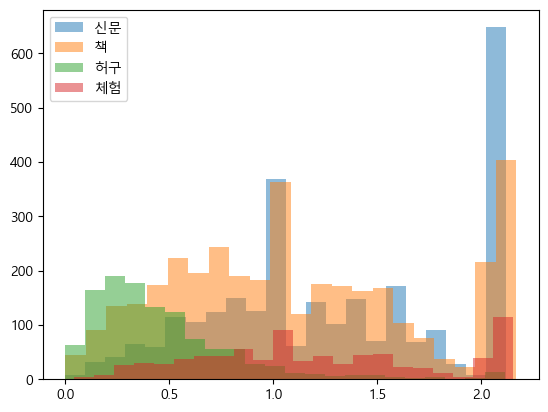

In [ ]:
# --------------------------------------------------
# . 추가 분석: T_RATE 대비 transition_rate의 비율 계산해서 히스토그램 그려보기
# --------------------------------------------------

# T_RATE 대비 transition_rate의 비율 계산, 새로운 컬럼 "transition_ratio_inside_T"에 저장
df["transition_ratio_inside_T"] = (
    df["transition_rate"] / df["T_RATE"]
)

print(
    df["transition_ratio_inside_T"]
    .round(1) # 소수점 둘째 자리까지 반올림
    .value_counts() #.sort_index() # 인덱스 기준으로 정렬 (즉, transition_ratio_inside_T 값이 작은 것부터 큰 것 순서로 정렬)
    .head(30)
    
)

# 문서범주별로 transition_ratio_inside_T의 히스토그램 그리기: plt.hist() 함수를 사용해서 각 문서범주별로 transition_ratio_inside_T의 분포를 히스토그램으로 그린다. bins=50은 히스토그램의 막대 개수를 50개로 설정하는 것이다. alpha=0.5는 히스토그램의 투명도를 0.5로 설정하는 것이다. label=cat은 범주별로 다른 색깔과 범례를 표시하기 위해 사용한다.

for cat in df["문서범주"].unique():
    sub = df[df["문서범주"] == cat]

    plt.hist(
        sub["transition_ratio_inside_T"], # 히스토그램으로 그릴 데이터 (transition_ratio_inside_T 컬럼)
        
        bins=22, # 히스토그램의 막대 개수
        alpha=0.5, # 투명도 조절 (필요에 따라 조정 가능, 너무 낮추면 히스토그램이 너무 옅어질 수 있다, 일반적으로 alpha=0.5~0.8 사이에서 조절한다)
        label=cat # 범주별로 색깔을 다르게 하기 위해 사용
    )

plt.legend()

전체 행 수: 896
x_col 숫자 변환 성공: 810
y_col 숫자 변환 성공: 810
그래프에 실제로 사용되는 행 수: 810

숫자 변환 후 앞부분:
     T_RATE  전환의확률비
40     96.6   1.036
88     94.6   1.057
98     94.2   1.061
181    91.9   0.622
377    87.2   1.051


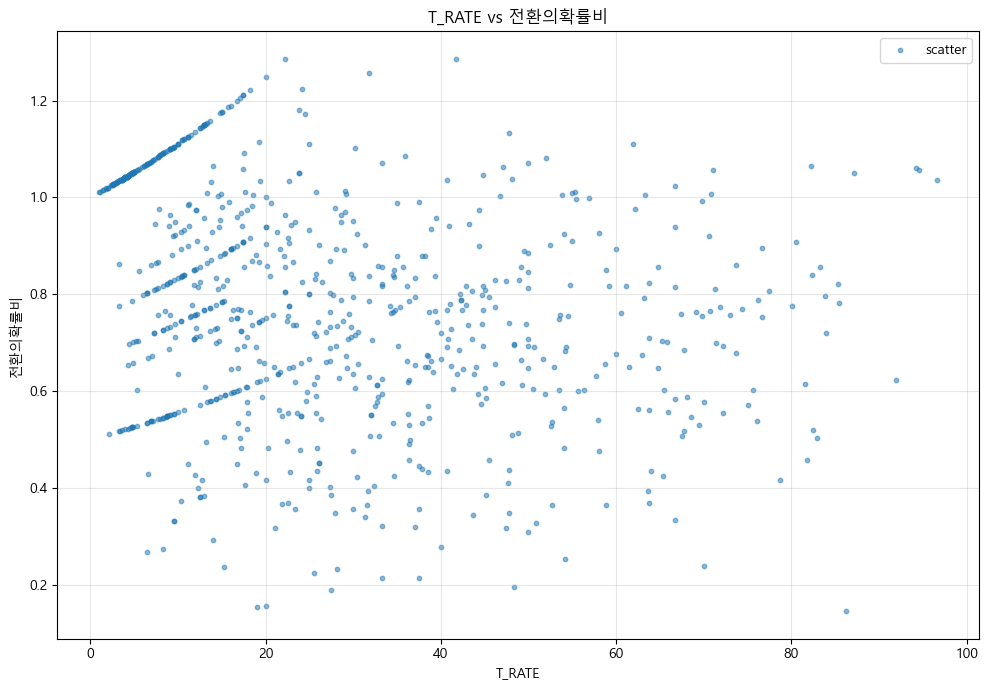

,T_RATE,전환의확률비
40,96.6,1.036
88,94.6,1.057
98,94.2,1.061
181,91.9,0.622
377,87.2,1.051
...,...,...
8305,1.8,1.018
8318,1.5,1.015
8324,1.4,1.015
8332,1.1,1.011


In [117]:
# 산점도

target_category = "체험"
sub_df = df[df["문서범주"] == target_category]

plot_transition_graph(
    sub_df,
    x_col="T_RATE",
    y_col='전환의확률비',
    #group_col="문서범주",
    show_scatter=True,
    show_expected=False
)



In [110]:
print(df[y_col].nunique())

541


In [35]:
print(
    df[y_col]
    .value_counts()
    .head(30)
)

전환의확률비
1.050    111
1.053     96
1.048     70
1.111     65
1.056     61
0.833     57
0.750     54
1.100     51
1.045     51
1.105     47
0.938     47
0.758     45
0.767     42
1.042     42
0.778     42
1.043     40
1.040     40
1.038     40
0.933     40
1.000     39
0.700     38
1.091     38
0.917     37
0.808     34
0.548     33
1.071     32
0.825     32
0.583     32
0.784     32
0.525     31
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 그룹별로 x_col에 따른 y_col의 분위선(예: 중앙값, 25% 분위, 75% 분위)을 그리는 함수
def plot_group_quantile_lines(
    df,
    x_col="T_RATE",
    y_col="transition_rate",
    group_col="문서범주",
    bin_width=5,
    min_count=10,
    show_scatter=True,
    figsize=(14, 9),
):

    data = df[[x_col, y_col, group_col]].dropna().copy()

    # 0~1 → 0~100 자동 변환
    if data[x_col].max() <= 1:
        data[x_col] *= 100

    if data[y_col].max() <= 1:
        data[y_col] *= 100

    # bin
    bins = np.arange(0, 100 + bin_width, bin_width)

    data["_bin"] = pd.cut(
        data[x_col],
        bins=bins,
        include_lowest=True,
        right=False
    )

    fig, ax = plt.subplots(figsize=figsize)

    colors = plt.cm.tab10.colors

    for idx, (group, sub) in enumerate(data.groupby(group_col)):

        color = colors[idx % len(colors)]

        # scatter
        if show_scatter:

            ax.scatter(
                sub[x_col],
                sub[y_col],
                s=14,
                alpha=0.25,
                color=color,
                label=group
            )

        # 분위 계산
        q = (
            sub
            .groupby("_bin", observed=True)
            .agg(
                x_mid=(x_col, "mean"),
                count=(y_col, "size"),

                q25=(y_col, lambda s: s.quantile(0.25)),
                median=(y_col, "median"),
                q75=(y_col, lambda s: s.quantile(0.75)),
            )
            .reset_index()
        )

        q = q[q["count"] >= min_count]

        # 중앙선
        ax.plot(
            q["x_mid"],
            q["median"],
            linewidth=3,
            color=color,
            label=f"{group} median"
        )

        # 분위선
        ax.plot(
            q["x_mid"],
            q["q25"],
            linestyle="--",
            linewidth=1.8,
            color=color,
            alpha=0.85
        )

        ax.plot(
            q["x_mid"],
            q["q75"],
            linestyle="--",
            linewidth=1.8,
            color=color,
            alpha=0.85
        )

    # -----------------------------
    # 기대 전환률 곡선
    # -----------------------------

    p_vals = np.linspace(0, 100, 1000) # 0부터 100까지 1000개의 점을 생성한다. 이 점들은 출현률을 나타낸다.

    expected = (
        2 * (p_vals / 100) * (1 - (p_vals / 100))
    ) * 100

    ax.plot(
        p_vals,
        expected,
        color="black",
        linewidth=3,
        label="Expected transition rate"
    )

    ax.set_xlabel(x_col) # x축 레이블 설정
    ax.set_ylabel(y_col) # y축 레이블 설정

    ax.set_title( # 그래프 제목 설정
        f"{y_col} quantile lines by {group_col}"
    )

    ax.grid(True) # 격자 추가

    ax.legend() # 범례 표시

    plt.show()

In [83]:
plot_group_quantile_lines(
    df,
    x_col="T_RATE",
    y_col="transition_rate",
    group_col="문서범주",
    bin_width=5,
    min_count=10,
    show_scatter=True
)

NameError: name 'plot_group_quantile_lines' is not defined

In [5]:
df.head(5)

,docu_id,n_T,n_F,n_sentences,P_T,P_F,TT,TF,FT,FF,...,switch_extension_ratio_vs_baseline,stay_stay_Obs_rate,stay_stay_E_rate,stay_stay_delta_vs_baseline,stay_stay_ratio_vs_baseline,stay_switch_Obs_rate,stay_switch_E_rate,stay_switch_delta_vs_baseline,stay_switch_ratio_vs_baseline,문서범주
0,AA0001.021,1.0,20.0,21.0,0.047619,0.952381,0.0,1.0,1.0,18.0,...,1.055556,0.842105,0.847645,-0.005540,0.993464,0.052632,0.047091,0.005540,1.117647,신문
1,AA0001.065,1.0,18.0,19.0,0.052632,0.947368,0.0,1.0,1.0,16.0,...,1.062500,0.823529,0.830450,-0.006920,0.991667,0.058824,0.051903,0.006920,1.133333,신문
2,AA0001.071,6.0,18.0,24.0,0.250000,0.750000,5.0,1.0,0.0,17.0,...,1.000000,0.909091,0.916667,-0.007576,0.991736,0.045455,0.037879,0.007576,1.200000,신문
3,AA0002.232,1.0,22.0,23.0,0.043478,0.956522,0.0,1.0,1.0,20.0,...,1.050000,0.857143,0.861678,-0.004535,0.994737,0.047619,0.043084,0.004535,1.105263,신문
4,AA0003.001,6.0,25.0,31.0,0.193548,0.806452,4.0,2.0,2.0,22.0,...,1.263158,0.724138,0.755747,-0.031609,0.958175,0.137931,0.106322,0.031609,1.297297,신문


전체 행 수: 9100
x_col 숫자 변환 성공: 8294
y_col 숫자 변환 성공: 8294
그래프에 실제로 사용되는 행 수: 8294

category 값:
문서범주
인문자연    3620
신문      2711
허구      1154
체험       809
Name: count, dtype: int64

숫자 변환 후 앞부분:
        P_T  switch_return_delta_vs_baseline 문서범주     docu_id
0  0.047619                        -0.002770   신문  AA0001.021
1  0.052632                        -0.003460   신문  AA0001.065
2  0.250000                         0.000000   신문  AA0001.071
3  0.043478                        -0.002268   신문  AA0002.232
4  0.193548                        -0.028736   신문  AA0003.001


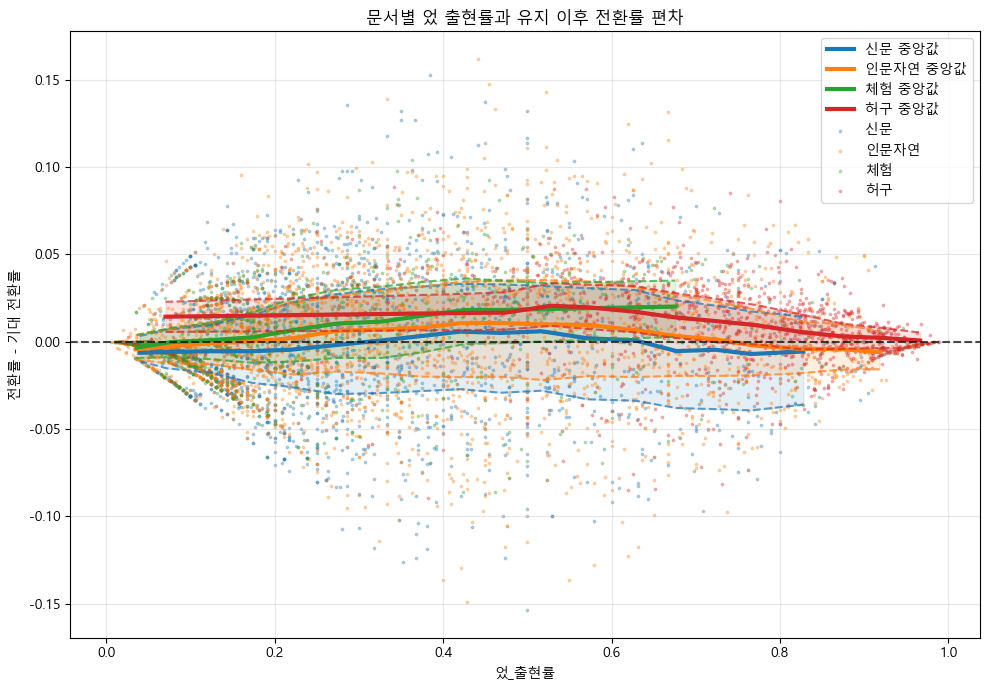

In [114]:
# 3연쇄 분석용 산점도와 분위선 그리기
X_COL_NAME_ = "P_T"
Y_COL_NAME_ = "switch_return_delta_vs_baseline"
GROUP_COL_NAME_ = "문서범주"
LABEL_COL_NAME_ = "docu_id"

set_korean_font()
fig, ax = plt.subplots(figsize=(10, 7))
if X_COL_NAME_ in df.columns and Y_COL_NAME_ in df.columns:
    data = prepare_xy_group_data(df,X_COL_NAME_,Y_COL_NAME_, GROUP_COL_NAME_, LABEL_COL_NAME_, percent_to_ratio=False)
    print_plot_summary(df, data, X_COL_NAME_, Y_COL_NAME_, GROUP_COL_NAME_)

if data.empty:
    print("No data available for plotting.")
else:
    # 기대 전환률 곡선 그리기
    draw_group_quantile_lines(
        data,  X_COL_NAME_, Y_COL_NAME_, GROUP_COL_NAME_,
        ax=ax,
        bin_width=0.05, # 0~1 비율 자료이므로 bin_width를 0.05로 지정한다.
        min_count=20, # 각 bin에 최소 20개 이상의 데이터가 있어야 분위선을 그리도록 한다.
        show_median=True,
        show_q_lines=True,
        show_q_band=True,
        smooth_window=5 # 분위선을 5-bin 이동평균으로 smoothing 한다. None 또는 1이면 smoothing 하지 않는다.
    )
    # 산점도 그리기
    draw_group_scatter(
        data, X_COL_NAME_, Y_COL_NAME_, GROUP_COL_NAME_,LABEL_COL_NAME_,
        ax=ax,
        show_labels=False,
        alpha=0.3, # 산점도 점의 투명도 (필요에 따라 조정 가능, 너무 낮추면 점이 너무 옅어질 수 있다, 일반적으로 alpha=0.5~0.8 사이에서 조절한다.)
        point_size=3 # 산점도 점 크기 (필요에 따라 조정 가능, 너무 작으면 점이 잘 안보일 수 있고, 너무 크면 점이 겹쳐서 보기가 어려울 수 있다. 일반적으로 point_size=3~10 사이에서 조절한다.
    )

    # 축 라벨
    ax.set_xlabel(X_COL_NAME_)
    ax.set_ylabel(Y_COL_NAME_)
    ax.set_title(f"{Y_COL_NAME_} by {GROUP_COL_NAME_}")
    ax.grid(True, alpha=0.3)

    # 범례
    ax.legend()#ax.legend(loc="center left",bbox_to_anchor=(1.02, 0.5))     # 범례를 그래프 밖 오른쪽에 배치한다.
    ax.axhline(y=0,  color="black", linewidth=1.5, linestyle="--", label="Baseline (zero line)", alpha=0.7) # y=0 기준선 추가

    # 축 라벨
    ax.set_xlabel("었_출현률")
    ax.set_ylabel("전환률 - 기대 전환률")
    ax.set_title(f"문서별 었 출현률과 유지 이후 전환률 편차")

    plt.tight_layout()
    plt.show()

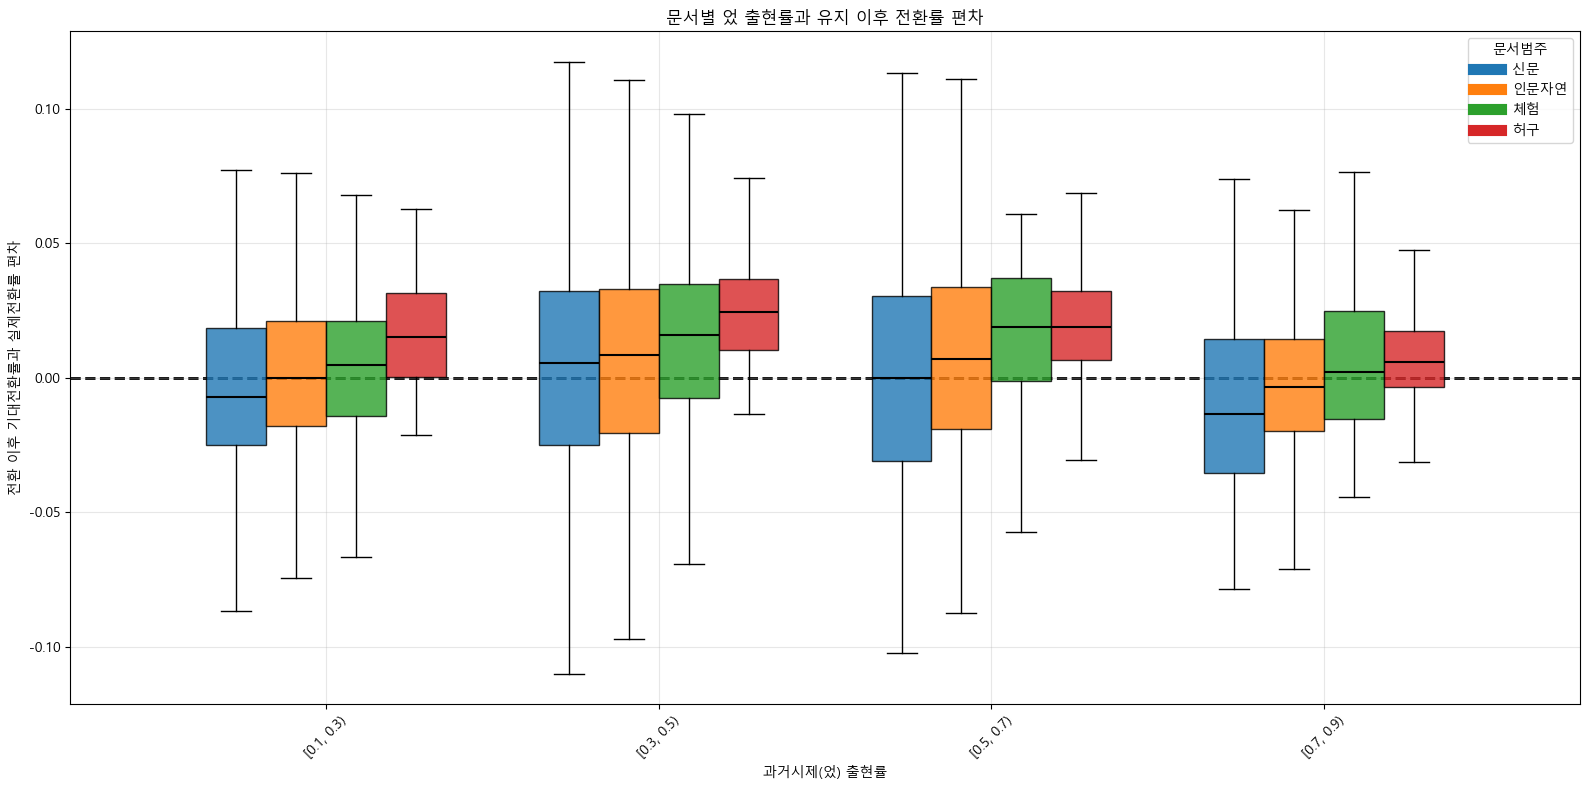

In [115]:
# 3연쇄 박스플롯 그리기, 2연쇄 분석용 CSV 파일에서 P_T 대비 switch_return_delta_vs_baseline의 박스플롯을 문서범주별로 그려보기
X_COL_NAME_ = "P_T"
Y_COL_NAME_ = "switch_return_delta_vs_baseline"
GROUP_COL_NAME_ = "문서범주"
LABEL_COL_NAME_ = "docu_id"

if X_COL_NAME_ in df.columns and Y_COL_NAME_ in df.columns:
    data = prepare_xy_group_data(
            df=df,
            x_col=X_COL_NAME_,
            y_col=Y_COL_NAME_,
            group_col=GROUP_COL_NAME_,
            label_col=LABEL_COL_NAME_,
            percent_to_ratio=False
        )
    data_mid = data[
        (data[X_COL_NAME_] >= 0.1)
        &
        (data[X_COL_NAME_] <= 0.9)
    ]

if len(data_mid) > 0:
    fig, ax = plt.subplots(figsize=(16, 8))

    plot_binned_boxplot(
        data=data_mid,
        x_col=X_COL_NAME_,
        y_col=Y_COL_NAME_,
        group_col=GROUP_COL_NAME_,
        bin_width=0.2,
        ax=ax,
        showfliers=False
    )
    ax.axhline(y=0,  color="black", linewidth=2, linestyle="--", label="Baseline (zero line)", zorder=0) # y=0에 수평선 추가, zorder=0으로 설정하여 다른 그래프 요소보다 아래에 그려지도록 한다.
    ax.set_title("문서별 었 출현률과 유지 이후 전환률 편차")     # 나중에 제목 변경
    ax.set_xlabel("과거시제(었) 출현률")
    ax.set_ylabel("전환 이후 기대전환률과 실제전환률 편차")
    plt.tight_layout()
    plt.show()

In [43]:
df_2.head(5)

,docu_id,n_T,n_F,n,n_sequences,a_TT,b_TF,c_FT,d_FF,k,...,Var_k,z_k,p_two_sided_z,p_lower_exact,p_upper_exact,p_two_exact,E_a,pearson_a,OR,log_OR
0,AA0001.021,1.0,20.0,21.0,1.0,0.0,1.0,1.0,18.0,2.0,...,0.086168,0.324443,0.745603,1.000000,0.904762,1.000000,0.050000,-0.223607,4.111111,1.413693
1,AA0001.065,1.0,18.0,19.0,1.0,0.0,1.0,1.0,16.0,2.0,...,0.094183,0.342997,0.731601,1.000000,0.894737,1.000000,0.055556,-0.235702,3.666667,1.299283
2,AA0001.071,6.0,18.0,24.0,1.0,5.0,1.0,0.0,17.0,1.0,...,3.130435,-4.521553,0.000006,0.000015,1.000000,0.000015,1.304348,3.235895,128.333333,4.854631
3,AA0002.232,1.0,22.0,23.0,1.0,0.0,1.0,1.0,20.0,2.0,...,0.079395,0.308607,0.757621,1.000000,0.913043,1.000000,0.045455,-0.213201,4.555556,1.516347
4,AA0003.001,6.0,25.0,31.0,1.0,4.0,2.0,2.0,22.0,4.0,...,2.799168,-3.393412,0.000690,0.002568,0.999632,0.002568,1.200000,2.556039,16.200000,2.785011


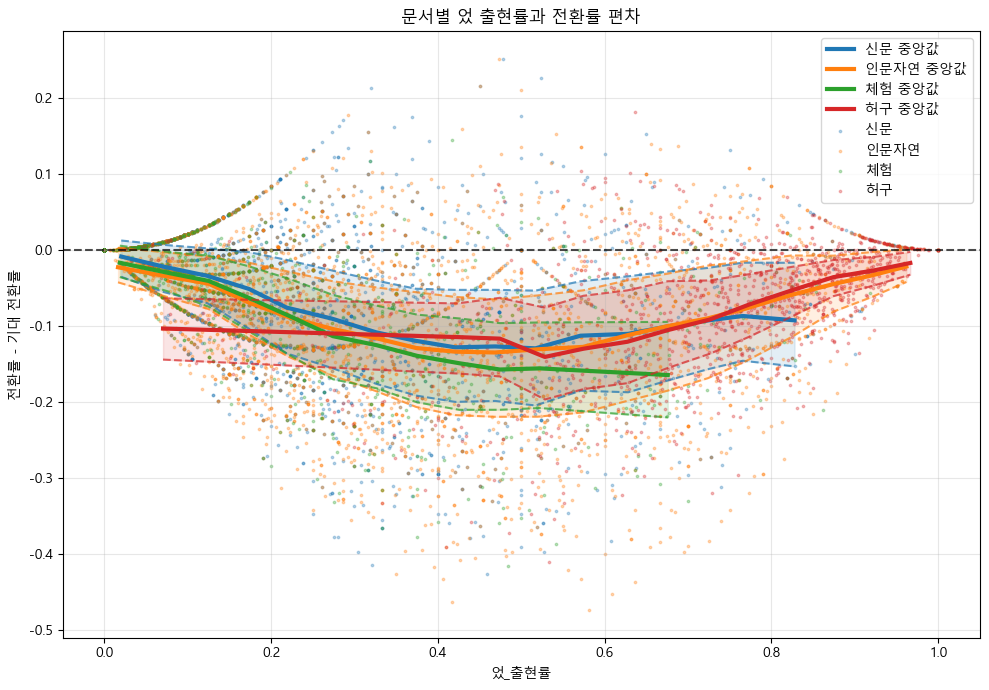

In [99]:
#2연쇄의 산점도
df_2["P_T"] = df_2['n_T'] / df_2['n']
X_COL_NAME_ = "P_T"
Y_COL_NAME_ = "delta_transition_rate"
GROUP_COL_NAME_ = "문서범주"
LABEL_COL_NAME_ = "docu_id"



set_korean_font()
fig, ax = plt.subplots(figsize=(10, 7))
if X_COL_NAME_ in df_2.columns and Y_COL_NAME_ in df_2.columns:
    data = prepare_xy_group_data(df_2, X_COL_NAME_, Y_COL_NAME_, GROUP_COL_NAME_, LABEL_COL_NAME_, percent_to_ratio=False)

if data.empty:
    print("No data available for plotting.")
else:
    # 기대 전환률 곡선 그리기
    draw_group_quantile_lines(
        data,  X_COL_NAME_, Y_COL_NAME_, GROUP_COL_NAME_,
        ax=ax,
        bin_width=0.05, # 0~1 비율 자료이므로 bin_width를 0.05로 지정한다.
        min_count=20, # 각 bin에 최소 20개 이상의 데이터가 있어야 분위선을 그리도록 한다.
        show_median=True,
        show_q_lines=True,
        show_q_band=True,
        smooth_window=5 # 분위선을 5-bin 이동평균으로 smoothing 한다. None 또는 1이면 smoothing 하지 않는다.
    )
    # 산점도 그리기
    draw_group_scatter(
        data, X_COL_NAME_, Y_COL_NAME_, GROUP_COL_NAME_,LABEL_COL_NAME_,
        ax=ax,
        show_labels=False,
        alpha=0.3, # 산점도 점의 투명도 (필요에 따라 조정 가능, 너무 낮추면 점이 너무 옅어질 수 있다, 일반적으로 alpha=0.5~0.8 사이에서 조절한다.)
        point_size=3 # 산점도 점 크기 (필요에 따라 조정 가능, 너무 작으면 점이 잘 안보일 수 있고, 너무 크면 점이 겹쳐서 보기가 어려울 수 있다. 일반적으로 point_size=3~10 사이에서 조절한다.
    )

    # 축 라벨
    ax.set_xlabel("었_출현률")
    ax.set_ylabel("전환률 - 기대 전환률")
    ax.set_title(f"문서별 었 출현률과 전환률 편차")
    ax.grid(True, alpha=0.3)

    # 범례
    ax.legend()#ax.legend(loc="center left",bbox_to_anchor=(1.02, 0.5))     # 범례를 그래프 밖 오른쪽에 배치한다.
    ax.axhline(y=0,  color="black", linewidth=1.5, linestyle="--", label="Baseline (zero line)", alpha=0.7) # y=0 기준선 추가

    plt.tight_layout()
    plt.show()


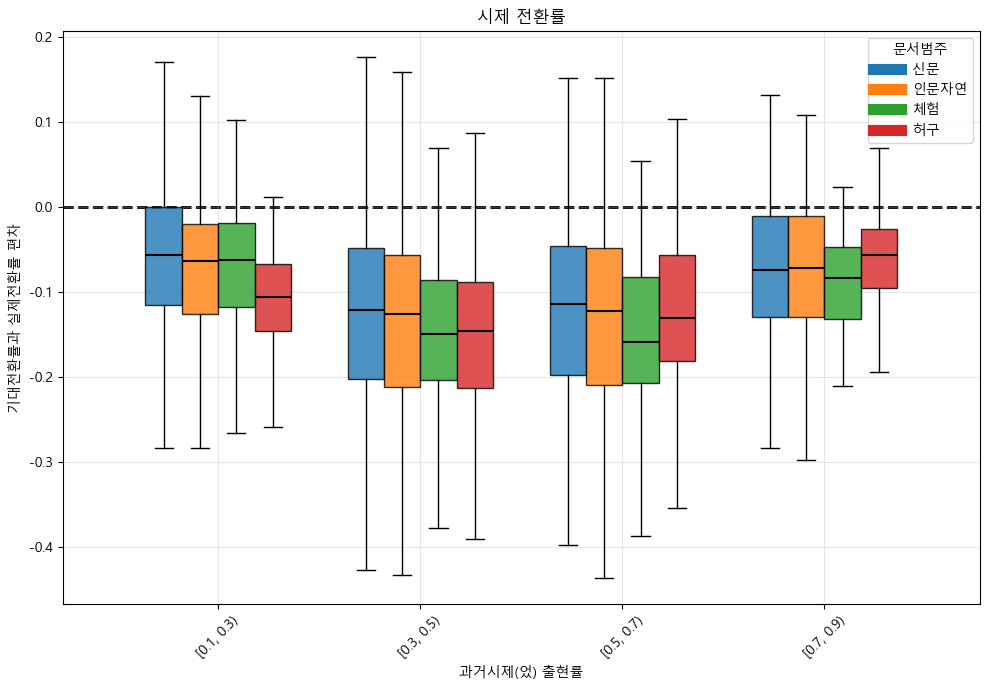

In [70]:
# 2연쇄 박스플롯 그리기, 2연쇄 분석용 CSV 파일에서 P_T 대비 switch_return_delta_vs_baseline의 박스플롯을 문서범주별로 그려보기

if X_COL_NAME_ in df_2.columns and Y_COL_NAME_ in df_2.columns:
    data2 = prepare_xy_group_data(
            df=df_2,
            x_col=X_COL_NAME_,
            y_col=Y_COL_NAME_,
            group_col=GROUP_COL_NAME_,
            label_col=LABEL_COL_NAME_,
            percent_to_ratio=False
        )

if len(data2) > 0:
    fig, ax = plt.subplots(figsize=(10, 7   ))

    plot_binned_boxplot(
        data=data2,
        x_col=X_COL_NAME_,
        y_col=Y_COL_NAME_,
        group_col=GROUP_COL_NAME_,
        bin_width=0.2,
        bin_start=0.1,
        bin_end=0.9,
        ax=ax,
        showfliers=False
    )

    ax.set_title("시제 전환률")     # 나중에 제목 변경
    ax.set_xlabel("과거시제(었) 출현률")
    ax.set_ylabel("기대전환률과 실제전환률 편차")
    
    ax.axhline(y=0,  color="black", linewidth=2, linestyle="--", label="Baseline (zero line)", zorder=0) # y=0에 수평선 추가, zorder=0으로 설정하여 다른 그래프 요소보다 아래에 그려지도록 한다.
    plt.tight_layout()
    plt.show()

